In [1]:
!pip install -q google-genai

In [61]:
from google.colab import userdata
import os

os.environ['GEMINI_API_KEY'] = userdata.get('GEMINI_API_KEY')

In [62]:
from google import genai

cliente = genai.Client()

In [4]:
respuesta = cliente.models.generate_content(
    model="gemini-2.5-flash",
    contents="¿Que provincia del Perú es buena para disfrutar de sus paisajes?"
)

print(respuesta.text)

Perú es un país increíblemente diverso en paisajes, por lo que **muchas provincias ofrecen vistas espectaculares**. La elección dependerá mucho del tipo de paisaje que busques (montañas, selva, desierto, costa).

Aquí te menciono algunas provincias y departamentos que son excelentes para disfrutar de sus paisajes, agrupados por tipo:

---

### **1. Paisajes de Montaña y Alta Cordillera (Andes)**

Si buscas montañas imponentes, glaciares, lagunas de color turquesa y valles andinos espectaculares, estas son las mejores:

*   **Departamento de Áncash (Provincias de Huaraz, Yungay, Carhuaz, etc. en el Callejón de Huaylas):**
    *   **Por qué:** Es el paraíso del trekking y la alta montaña en Perú. Alberga el **Parque Nacional Huascarán** y la majestuosa **Cordillera Blanca**, con picos nevados que superan los 6000 m.s.n.m., lagunas glaciares de colores vibrantes (como la Laguna 69, Llanganuco), valles profundos y paisajes andinos impresionantes. **Si tu prioridad son las montañas, Áncash 

In [5]:
from google.colab import files

os.makedirs("PDFs", exist_ok=True)
uploader = files.upload()

for archivo in uploader.keys():
  os.rename(archivo, f"PDFs/{archivo}")

Saving Carrarurquia_Reporte_Q1_2025.pdf to Carrarurquia_Reporte_Q1_2025.pdf
Saving Carrarurquia_Reporte_Q2_2025.pdf to Carrarurquia_Reporte_Q2_2025.pdf
Saving Carrarurquia_Reporte_Q3_2025.pdf to Carrarurquia_Reporte_Q3_2025.pdf
Saving Carrarurquia_Reporte_Q4_2025.pdf to Carrarurquia_Reporte_Q4_2025.pdf


In [6]:
!pip install -q langchain-community pypdf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 40.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 333.7/333.7 kB 29.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 22.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 4.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.


In [7]:
from langchain_community.document_loaders import PyPDFLoader

In [8]:
documentos = []

for archivo2 in os.listdir("PDFs"):
  ruta = os.path.join("PDFs", archivo2)
  loader = PyPDFLoader(ruta)
  paginas = loader.load()
  documentos.extend(paginas)

In [9]:
documentos[0]

Document(metadata={'producer': 'ReportLab PDF Library - www.reportlab.com', 'creator': '(unspecified)', 'creationdate': '2026-02-13T13:49:44+00:00', 'author': '(anonymous)', 'keywords': '', 'moddate': '2026-02-13T13:49:44+00:00', 'subject': '(unspecified)', 'title': 'Carrarurquía - Reporte Q2 2025', 'trapped': '/False', 'source': 'PDFs/Carrarurquia_Reporte_Q2_2025.pdf', 'total_pages': 15, 'page': 0, 'page_label': '1'}, page_content='Carrarurquía\nReporte trimestral Q2 2025 (ficticio)\nPeriodo: 01/04/2025 - 30/06/2025\nMoneda: USD\n1\n Carrarurquía\n Reporte trimestral Q2 2025 · Viajes a Turquía (ficticio)\n Periodo: 01/04/2025 - 30/06/2025\n Moneda de referencia: dólares estadounidenses (USD)\nEste documento presenta resultados y aprendizajes ficticios del trimestre para Carrarurquía, una\nempresa de viajes especializada en experiencias en Turquía. Los datos, cifras y testimonios han sido\ncreados con fines demostrativos y no representan operaciones reales.\n Edición: Julio de 2025')

In [63]:
len(documentos)

60

In [11]:
!pip install -q langchain-text-splitters

In [12]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

divisor = RecursiveCharacterTextSplitter(
    chunk_size=400,
    chunk_overlap=40,
    separators=["\n\n", "\n", ". ", " ", ""]
)

fragmentos = divisor.split_documents(documentos)

In [13]:
fragmentos[67]

Document(metadata={'producer': 'ReportLab PDF Library - www.reportlab.com', 'creator': '(unspecified)', 'creationdate': '2026-02-13T13:49:44+00:00', 'author': '(anonymous)', 'keywords': '', 'moddate': '2026-02-13T13:49:44+00:00', 'subject': '(unspecified)', 'title': 'Carrarurquía - Reporte Q3 2025', 'trapped': '/False', 'source': 'PDFs/Carrarurquia_Reporte_Q3_2025.pdf', 'total_pages': 15, 'page': 10, 'page_label': '11'}, page_content='Riesgo\nProbabilidad\nImpacto\nMitigación principal\nSobrecupo hotelero en picos\nMedia\nAlto\nCupos firmes + lista de hoteles\nalternativos con precios\npre-negociados.\nIncidencias en traslados\ninternos\nMedia\nMedio\nMonitoreo de rutas + buffer de horarios\n+ partners con back-up.\nVariación de precios de\nproveedores\nAlta\nMedio\nCláusulas de ajuste y revisión\nquincenal de tarifas en temporada.')

In [14]:
!pip install -q langchain-google-genai faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 20.4 MB/s eta 0:00:00


In [64]:
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from langchain_community.vectorstores import FAISS

embeddings = GoogleGenerativeAIEmbeddings(
    model="models/gemini-embedding-001"
)

In [16]:
len(fragmentos)

172

In [17]:
vectorstore1 = FAISS.from_documents(
    documents=fragmentos[0:89],
    embedding=embeddings
)

In [18]:
vectorstore2 = FAISS.from_documents(
    documents=fragmentos[90:],
    embedding=embeddings
)

In [19]:
vectorstore1.index.reconstruct(0)

array([-0.00143831,  0.00889298,  0.01531782, ...,  0.01553657,
       -0.00974552, -0.02190461], dtype=float32)

In [20]:
len(vectorstore1.index.reconstruct(0))

3072

In [21]:
vectorstore1.merge_from(vectorstore2)

In [22]:
consulta = "Cuál es el paquete de viajes más económico de Carrarurquía?"

resultados = vectorstore1.similarity_search(
    consulta,
    k=7
)

for i in resultados:
  print(i)
  print("\n")

page_content='Carrarurquía
Reporte trimestral Q3 2025 (ficticio)
Periodo: 01/07/2025 - 30/09/2025
Moneda: USD
13
11. Apéndice A: Paquetes y tarifas de referencia
Lista simplificada de precios (USD)
Tarifas ficticias orientativas para paquetes populares. Los importes se muestran por persona en ocupación' metadata={'producer': 'ReportLab PDF Library - www.reportlab.com', 'creator': '(unspecified)', 'creationdate': '2026-02-13T13:49:44+00:00', 'author': '(anonymous)', 'keywords': '', 'moddate': '2026-02-13T13:49:44+00:00', 'subject': '(unspecified)', 'title': 'Carrarurquía - Reporte Q3 2025', 'trapped': '/False', 'source': 'PDFs/Carrarurquia_Reporte_Q3_2025.pdf', 'total_pages': 15, 'page': 12, 'page_label': '13'}


page_content='Carrarurquía
Reporte trimestral Q4 2025 (ficticio)
Periodo: 01/10/2025 - 31/12/2025
Moneda: USD
13
11. Apéndice A: Paquetes y tarifas de referencia
Lista simplificada de precios (USD)
Tarifas ficticias orientativas para paquetes populares. Los importes se muestran

In [23]:
from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0.2
)

retriever = vectorstore1.as_retriever(
    search_kwargs={"k": 4}
)

In [24]:
from IPython.display import Markdown, display

In [25]:
def preguntar_rag(pregunta):
    docs = retriever.invoke(pregunta)
    contexto = "\n\n---\n\n".join(doc.page_content for doc in docs)

    # AJUSTE EN EL PROMPT: Añadimos instrucciones de estilo
    prompt = f"""Eres un asistente experto que responde preguntas basándose ÚNICAMENTE
    en el contexto proporcionado.

    IMPORTANTE: Presenta la información de manera muy organizada y visual.
    - Usa títulos (###) para cada sección o reporte.
    - Usa listas con viñetas para los puntos clave.
    - Usa negritas para resaltar datos importantes.
    - Si hay métricas, preséntalas de forma clara.

    Si la información no está en el contexto, di que no tienes suficiente información.

    Contexto: {contexto}
    Pregunta: {pregunta}
    Respuesta:"""

    respuesta = llm.invoke(prompt)
    return respuesta.content


In [26]:

pregunta_usuario = "Dame el resumen ejecutivo de cada reporte y cuales fueron los buenos resultados que salio bien de cada trimestre?"
resultado = preguntar_rag(pregunta_usuario)

display(Markdown(resultado))

Aquí tienes el resumen ejecutivo y los buenos resultados de cada trimestre, basados únicamente en el contexto proporcionado:

### Reporte Trimestral Q4 2025

*   **Resumen Ejecutivo:**
    *   Q4 cerró el año con una demanda más orientada a **escapadas urbanas, gastronomía y experiencias culturales**.
    *   La estacionalidad permitió negociar **mejores tarifas hoteleras**.
    *   Se logró elevar el **margen bruto**.
    *   Se priorizó la **eficiencia**.

*   **Resultados Positivos / Lo que salió bien:**
    *   La demanda se orientó exitosamente hacia **escapadas urbanas, gastronomía y experiencias culturales**.
    *   Se negociaron **mejores tarifas hoteleras** gracias a la estacionalidad.
    *   Hubo una elevación del **margen bruto**.
    *   Se priorizó y, por implicación, se trabajó en la **eficiencia**.

### Reporte Trimestral Q3 2025

*   **Resumen Ejecutivo:**
    *   Q3 fue el trimestre de **mayor volumen del año**.
    *   Se experimentó un **pico de demanda en julio y agosto**.
    *   La prioridad operativa fue sostener la **calidad en plena temporada alta**.
    *   Se reforzó el **soporte en destino**.
    *   Se renegociaron **cupos**.

*   **Resultados Positivos / Lo que salió bien:**
    *   Fue el trimestre de **mayor volumen del año**.
    *   Se manejó exitosamente un **pico de demanda en julio y agosto**.
    *   Se logró sostener la **calidad** a pesar de ser temporada alta.
    *   Se reforzó el **soporte en destino**.
    *   Se renegociaron **cupos**.

### Reporte Trimestral Q2 2025

*   **Resumen Ejecutivo:**
    *   Q2 consolidó el **crecimiento** tras el arranque del año.
    *   Hubo un **incremento de la demanda internacional**.
    *   La operación fue más **estable en Estambul y Capadocia**.
    *   Se logró una **mejora del tiempo de respuesta en cotizaciones**.

*   **Resultados Positivos / Lo que salió bien:**
    *   Se consolidó el **crecimiento** después del inicio del año.
    *   Se observó un **incremento de la demanda internacional**.
    *   La operación fue más **estable en Estambul y Capadocia**.
    *   Hubo una **mejora en el tiempo de respuesta de las cotizaciones**.

In [27]:
pregunta_usuario = ("En la actualidad, quien es el presidente del peru?")
resultado = preguntar_rag(pregunta_usuario)
display(Markdown(resultado))

No tengo suficiente información en el contexto proporcionado para responder quién es el presidente de Perú.

In [28]:
!pip install -q langgraph google-search-results markdown fpdf2

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.0/81.0 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.1/327.1 kB 14.7 MB/s eta 0:00:00


In [29]:
os.environ['SERPAPI_API_KEY'] = userdata.get('SERPAPI_API_KEY')

In [ ]:
from langchain_community.utilities import SerpAPIWrapper
from langchain_google_genai import ChatGoogleGenerativeAI

# buscador
buscador = SerpAPIWrapper()

# LLM
llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0.2
)

def buscar_y_formatear(pregunta):
    resultado_crudo = buscador.run(pregunta)

    prompt = f"""
Eres un asistente que organiza información de internet de forma clara y útil.

Tu tarea es transformar el siguiente resultado en un formato estructurado.

IMPORTANTE:
- Usa títulos (###)
- Usa listas con viñetas
- Resume la información
- Destaca datos clave en negrita
- Si hay números o estadísticas, resáltalos

Resultado crudo:
{resultado_crudo}

Pregunta: {pregunta}

Respuesta estructurada:
"""

    respuesta = llm.invoke(prompt)
    return respuesta.content


pregunta = "¿Cuántos atletas turcos fueron a las olimpiadas de invierno 2026?"
resultado = buscar_y_formatear(pregunta)

from IPython.display import Markdown
display(Markdown(resultado))

Construir el grafo con LangGraph

> Añadir blockquote




```
                    ┌─── "rag" ───→ [Buscar en documentos] ───┐
[START] → [Agente]                                         → [Generar Markdown] → END
                    └─── "web" ───→ [Buscar en la web] ───────┘
```

In [33]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

class AgentState(TypedDict):
  pregunta: str
  fuente: str
  contexto: str
  respuesta: str

In [34]:
def nodo_agente(state: AgentState):
  pregunta = state["pregunta"]

  prompt = f"""Eres un clasificador. Dada la siguiente pregunta, decide si se debe
  responder buscando en los DOCUMENTOS LOCALES (PDFs cargados) de la empresa Carrarurquía o
  informaciones más generales en la WEB (internet).
  Reglas:
  - Responde SOLO con la palabra 'RAG' si la pregunta se refiere al contenido de documentos cargados
  - Responde SOLO con la palabra 'Web' si la pregunta requiere información actualizada, de temas generales, de la web

  Pregunta: {pregunta}

  Respuesta (RAG o Web):"""

  respuesta = llm.invoke(prompt)

  fuente = respuesta.content.strip()

  if "RAG" in fuente:
    fuente = "RAG"
  else:
    fuente = "Web"

  print(f"El agente decidió la fuente {fuente}.")
  return {"fuente": fuente}

In [35]:
def nodo_rag(state: AgentState):

  contexto = preguntar_rag(state["pregunta"])

  return {"contexto": contexto}

In [36]:
def nodo_web(state: AgentState):

  contexto = buscador.run(state["pregunta"])

  return {"contexto": contexto}

In [49]:
def nodo_markdown(state: AgentState):

  prompt = f"""
Eres un asistente experto.

FORMATO OBLIGATORIO:
- Usa Markdown limpio y válido
- Usa # para títulos
- Usa ## para subtítulos
- Usa listas con *
- NO incluyas texto con \\n
- NO repitas contenido
- NO generes versiones duplicadas

Responde SOLO en Markdown bien formateado.

Contexto:
{state["contexto"]}

Pregunta: {state["pregunta"]}

Respuesta:"""

  respuesta = llm.invoke(prompt)

  return {"respuesta": respuesta.content}

In [38]:
def decidir_fuente(state: AgentState):

  if state["fuente"] == "RAG":
    return "RAG_elegido"
  elif state["fuente"] == "Web":
    return "Web_elegida"
  else:
    return "Error!"

In [39]:
grafo = StateGraph(AgentState)

grafo.add_node("Agente", nodo_agente)
grafo.add_node("RAG", nodo_rag)
grafo.add_node("Web", nodo_web)
grafo.add_node("Markdown", nodo_markdown)

grafo.add_edge(START, "Agente")
grafo.add_conditional_edges("Agente", decidir_fuente,
                            {"RAG_elegido": "RAG",
                             "Web_elegida": "Web"})
grafo.add_edge("RAG", "Markdown")
grafo.add_edge("Web", "Markdown")
grafo.add_edge("Markdown", END)

In [40]:
agente = grafo.compile()

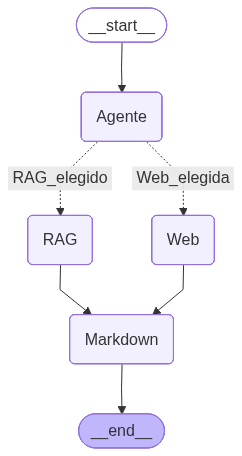

In [41]:
from IPython.display import Image, display

imagen = agente.get_graph().draw_mermaid_png()
display(Image(imagen))

In [57]:
from IPython.display import Markdown, display

def ejecutar_agente(pregunta):

  resultado = agente.invoke({
      "pregunta": pregunta,
      "fuente": "",
      "contexto": "",
      "respuesta": ""
  })

  respuesta_final = resultado["respuesta"]

  print("=" * 60)
  print(f"Fuente utilizada: {resultado['fuente']}")
  print("=" * 60)

  print("\n📄 CONTEXTO:\n")
  display(Markdown(resultado["contexto"]))

  print("\n🤖 RESPUESTA FINAL:\n")
  display(Markdown(respuesta_final))

  return respuesta_final

In [60]:
pip install reportlab

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 27.3 MB/s eta 0:00:00


In [ ]:
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer
from reportlab.lib.styles import getSampleStyleSheet

def exportar_pdf(texto, nombre_archivo="reporte.pdf"):

    doc = SimpleDocTemplate(nombre_archivo)
    estilos = getSampleStyleSheet()
    elementos = []

    # dividir por líneas
    lineas = texto.split("\n")

    for linea in lineas:
        linea = linea.strip()

        if not linea:
            elementos.append(Spacer(1, 10))
            continue

        # Títulos
        if linea.startswith("# "):
            elementos.append(Paragraph(f"<b>{linea[2:]}</b>", estilos["Heading1"]))
        elif linea.startswith("## "):
            elementos.append(Paragraph(f"<b>{linea[3:]}</b>", estilos["Heading2"]))
        elif linea.startswith("* "):
            elementos.append(Paragraph(f"• {linea[2:]}", estilos["Normal"]))
        else:
            elementos.append(Paragraph(linea, estilos["Normal"]))

    doc.build(elementos)

In [58]:
respuesta_final = ejecutar_agente("Dónde se mantuvo concentrado el mix de productos?")

exportar_pdf(respuesta_final, "reporte_agente.pdf")

ChatGoogleGenerativeAIError: Error calling model 'gemini-2.5-flash' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash\nPlease retry in 9.039399991s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerDayPerProjectPerModel-FreeTi